# Assignment 8: Dimensionality Reduction

Dataset(s) needed: MNIST ("Modified National Institute of Standards and Technology") dataset.

# Learning Objectives
- Be able to make application decisions regarding principal component analysis to train and test data 
- Produce a dimensionality reduction model.

In [1]:
#Load the MNIST dataset
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', parser="pandas")

In [2]:
mnist["data"].dtypes

pixel1      int64
pixel2      int64
pixel3      int64
pixel4      int64
pixel5      int64
            ...  
pixel780    int64
pixel781    int64
pixel782    int64
pixel783    int64
pixel784    int64
Length: 784, dtype: object

In [3]:
mnist["target"].dtypes

CategoricalDtype(categories=['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'], ordered=False)

## Question 1: Split the data into a training set and a test set (take the first 60,000 instances for training, and the remaining 10,000 for testing).

In [4]:
X_train = mnist["data"][:60000]
y_train = mnist["target"][:60000].astype(int) #dtype is category, changing it to int

X_test = mnist["data"][60000:]
y_test = mnist["target"][60000:].astype(int)  #dtype is category, changing it to int

## Question 2: Train a Logistic Regression classifier on the dataset. Set solver = lbfgs and random_state = 42. Hint you might also want to think about the multi_class parameter and if you need to set that.  You want to track how long the model takes to run.

In [5]:
from sklearn.linear_model import LogisticRegression
import time
import pandas as pd

In [6]:
#Preprocessing
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(X_train,y_train)
X_train_minmax_scaled = scaler.transform(X_train)
X_test_minmax_scaled = scaler.transform(X_test)


In [7]:
start = time.time()

lr = LogisticRegression(random_state=42, solver='lbfgs').fit(X_train,y_train) #multiclass parameter is set to auto by default

end = time.time()
deltat = end-start
print("Total Time Elapsed: ",round(deltat,2)," seconds")

Total Time Elapsed:  22.65  seconds


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [8]:
start = time.time()

lr_scaled = LogisticRegression(random_state=42, solver='lbfgs').fit(X_train_minmax_scaled,y_train) #multiclass parameter is set to auto by default

end = time.time()
deltat = end-start
print("Total Time Elapsed: ",round(deltat,2)," seconds")

Total Time Elapsed:  21.68  seconds


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Question 3: Evaluate the resulting model on the test set.

In [9]:
from sklearn.metrics import mean_squared_error

In [10]:
y_pred = lr.predict(X_test).astype(int)
y_pred_scaled = lr_scaled.predict(X_test_minmax_scaled).astype(int)

In [11]:
print("The MSE loss for this model with the test dataset is {}".format(mean_squared_error(y_test,y_pred)))
print("The MSE loss for this model (trained on scaled data) with the test dataset is {}".format(mean_squared_error(y_test,y_pred_scaled)))

The MSE loss for this model with the test dataset is 1.2852
The MSE loss for this model (trained on scaled data) with the test dataset is 1.3228


## Question 4: Use PCA to reduce the dataset's dimensionality, with an explained variance ratio of 95%.

In [12]:
df = pd.DataFrame(X_train,columns=mnist["frame"].columns.tolist())
df['y'] = y_train

In [13]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_train.values)
df['pca-one']   = pca_result[:,0]
df['pca-two']   = pca_result[:,1]
#df['pca-three'] = pca_result[:,2] #I was considering using more than two components for PCA but didn't see the point.
#df['pca-four']  = pca_result[:,3]
#df['pca-five']  = pca_result[:,4]
print('Explained variation per principal component: {}'.format(pca.explained_variance_ratio_))

Explained variation per principal component: [0.09704664 0.07095924]


<AxesSubplot:xlabel='pca-one', ylabel='pca-two'>

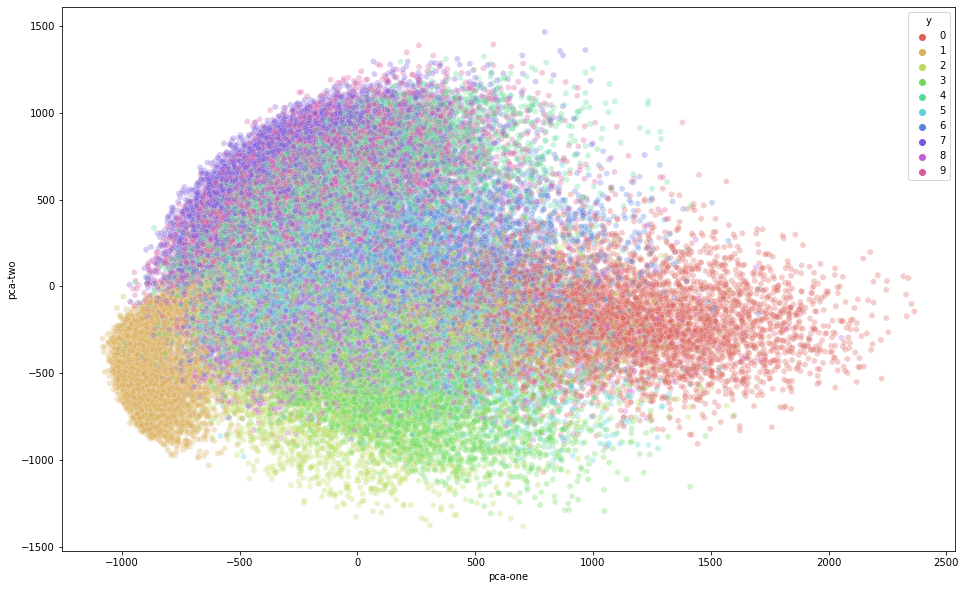

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(16,10))
sns.scatterplot(
    x="pca-one", y="pca-two",
    hue="y",
    palette=sns.color_palette("hls", 10),
    data=df,
    legend="full",
    alpha=0.3
)

## Question 5: Train a new Logistic Regression classifier on the reduced dataset and see how long it takes. Use the same criteria as before just with PCA. Was training much faster? Explain your results

In [14]:
start = time.time()

X_train_pca = pca.fit_transform(X_train)
lr = LogisticRegression(random_state=42, solver='lbfgs').fit(X_train_pca,y_train)

end = time.time()
deltat = end-start
print("Total Time Elapsed: ",round(deltat,2)," seconds")

Total Time Elapsed:  4.22  seconds


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [15]:
start = time.time()

X_train_mmscaled_pca = pca.fit_transform(X_train_minmax_scaled)
lr_scaled = LogisticRegression(random_state=42, solver='lbfgs').fit(X_train_mmscaled_pca,y_train) #multiclass parameter is set to auto by default

end = time.time()
deltat = end-start
print("Total Time Elapsed: ",round(deltat,2)," seconds")

Total Time Elapsed:  3.31  seconds


## Question 6: Evaluate the new classifier on the test set: how does it compare to the previous classifier? Discuss the speed / accuracy trade-off and in which case you'd prefer a very slight drop in model performance for a x-time speedup in training.

In [16]:
y_pred = lr.predict(pca.transform(X_test)).astype(int)
y_pred_scaled = lr_scaled.predict(pca.transform(X_test_minmax_scaled)).astype(int)
print("The MSE loss for this model with the test dataset is {}".format(mean_squared_error(y_test,y_pred)))
print("The MSE loss for this model (trained on scaled data) with the test dataset is {}".format(mean_squared_error(y_test,y_pred_scaled)))

The MSE loss for this model with the test dataset is 16.1181
The MSE loss for this model (trained on scaled data) with the test dataset is 7.8988


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:413: UserWarning: X has feature names, but PCA was fitted without feature names
  warnings.warn(


#### As expected, there's a natural trade off between the performance of the model and it's training duration, here we find that PCA expedites the training time an incredible deal. The difference in training duration is nearly a factor of ten, that is however accompanied by a degradation in model performance. Whether or not this tradeoff is deemed acceptable depends on the constraints the programmer has and on the expectations of the venture as a whole. If I were developing models in a research enviroment (I wish, hopefully as a career...) I could see how using PCA for dimensionality reduction to expeditite the training duration would be incredibly useful if I were trying to get a quick understanding of the situation and whether or not the model works well as opposed to spending more time to achieve the same conclusion; after this is done one might be interested in not applying PCA and exploring how much better the model might behave on the original dataset. After this point the researcher/programmer could determine whether or not they might prefer the speed enhancement over the models performance or not.

## Question 5. Create a new text cell in your Notebook: Complete a 50-100 word summary (or short description of your thinking in applying this week's learning to the solution) of your experience in this assignment. Include:
                                                                      
* What was your incoming experience with this model, if any? 
* What steps you took, what obstacles you encountered.
* How you link this exercise to real-world, machine learning problem-solving. (What steps were missing? What else do you need to learn?) 
> This summary allows your instructor to know how you are doing and allot points for your effort in thinking and planning, and making connections to real-world work.


#### Again, it's unfortunate that I don't have any incoming experience with either LR or PCA besides what I've learned so far, so naturally I did run into some issues when intially using them but beyond that I had relatively no issues completing this assignment. Compared to Lesson 6, the models on this dataset ran fairly quickly which I'm glad about, I did however run into one issue, persistent convergence warnings. I found that for nearly every case I was having convergence errors, even if I increased n_iter variable for the model, I assumed after sometime that it was unavoidable like in Lesson 7. What's important is after scaling the data and applying PCA, the model actually converged which, to my understanding, is the proper approach for such a case. I could see how this process of exploring alternative approaches to applying a model to obtian marginal performance increases would be done in relatively every field where ML is applied, if the amount of time and effort spent searching for a better approach is less expensive relative to the monetary increases that would result from such an improvement than this is more than a fruitful effort. I apologize for being unable to give a real-world example however, this is due to my lack of experience in the field and in applying ML.